# Limpeza e Preparação dos Dados — CAGED Telemarketing

Este notebook transforma os dados brutos coletados do CAGED em uma 
série temporal limpa e pronta para análise e forecasting.

**Input:** data/raw/caged_telemarketing_raw.csv  
**Output:** output/caged_telemarketing_tratado.csv

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregar os dados brutos
df = pd.read_csv('../data/raw/caged_telemarketing_raw.csv')

print(f"Dados carregados: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes)
print(f"\nPrimeiras linhas:")
df.head()

Dados carregados: (187, 3)

Tipos de dados:
ano               int64
mes               int64
saldo_empregos    int64
dtype: object

Primeiras linhas:


,ano,mes,saldo_empregos
0,2010,1,1998
1,2010,2,3405
2,2010,3,8439
3,2010,4,4311
4,2010,5,6213


In [9]:
# Criar coluna de data combinando ano e mês
df['data'] = pd.to_datetime(
    df['ano'].astype(str) + '-' + df['mes'].astype(str) + '-01'
)

# Ordenar cronologicamente
df = df.sort_values('data').reset_index(drop=True)

# Verificar
print("Coluna de data criada:")
print(df[['ano', 'mes', 'data', 'saldo_empregos']].head(10))
print(f"\nTipo da coluna data: {df['data'].dtype}")
print(f"\nPeríodo: {df['data'].min()} até {df['data'].max()}")

Coluna de data criada:
    ano  mes       data  saldo_empregos
0  2010    1 2010-01-01            1998
1  2010    2 2010-02-01            3405
2  2010    3 2010-03-01            8439
3  2010    4 2010-04-01            4311
4  2010    5 2010-05-01            6213
5  2010    6 2010-06-01            3873
6  2010    7 2010-07-01            3380
7  2010    8 2010-08-01            5365
8  2010    9 2010-09-01            6507
9  2010   10 2010-10-01            7942

Tipo da coluna data: datetime64[ns]

Período: 2010-01-01 00:00:00 até 2025-07-01 00:00:00


In [10]:
# Calcular estoque acumulado
df['estoque_acumulado'] = df['saldo_empregos'].cumsum()

# Verificar
print("Saldo vs Estoque acumulado:")
print(df[['data', 'saldo_empregos', 'estoque_acumulado']].head(15))
print(f"\nPico máximo de empregos: {df['estoque_acumulado'].max():,.0f}")
print(f"Nível atual (2024): {df['estoque_acumulado'].iloc[-1]:,.0f}")
print(f"Variação total: {df['estoque_acumulado'].iloc[-1] - df['estoque_acumulado'].iloc[0]:,.0f}")

Saldo vs Estoque acumulado:
         data  saldo_empregos  estoque_acumulado
0  2010-01-01            1998               1998
1  2010-02-01            3405               5403
2  2010-03-01            8439              13842
3  2010-04-01            4311              18153
4  2010-05-01            6213              24366
5  2010-06-01            3873              28239
6  2010-07-01            3380              31619
7  2010-08-01            5365              36984
8  2010-09-01            6507              43491
9  2010-10-01            7942              51433
10 2010-11-01            7795              59228
11 2010-12-01           -2867              56361
12 2011-01-01            1562              57923
13 2011-02-01            9370              67293
14 2011-03-01            5557              72850

Pico máximo de empregos: 274,195
Nível atual (2024): 253,466
Variação total: 251,468


In [11]:
# Encontrar quando foi o pico
idx_pico = df['estoque_acumulado'].idxmax()
data_pico = df.loc[idx_pico, 'data']
valor_pico = df.loc[idx_pico, 'estoque_acumulado']

# Calcular queda desde o pico
valor_atual = df['estoque_acumulado'].iloc[-1]
queda_absoluta = valor_pico - valor_atual
queda_percentual = (queda_absoluta / valor_pico) * 100

print(f"Pico de empregos: {data_pico.strftime('%B/%Y')}")
print(f"Valor no pico: {valor_pico:,.0f}")
print(f"Valor em Dez/2024: {valor_atual:,.0f}")
print(f"Queda absoluta: -{queda_absoluta:,.0f} empregos")
print(f"Queda percentual: -{queda_percentual:.1f}%")

Pico de empregos: November/2021
Valor no pico: 274,195
Valor em Dez/2024: 253,466
Queda absoluta: -20,729 empregos
Queda percentual: -7.6%


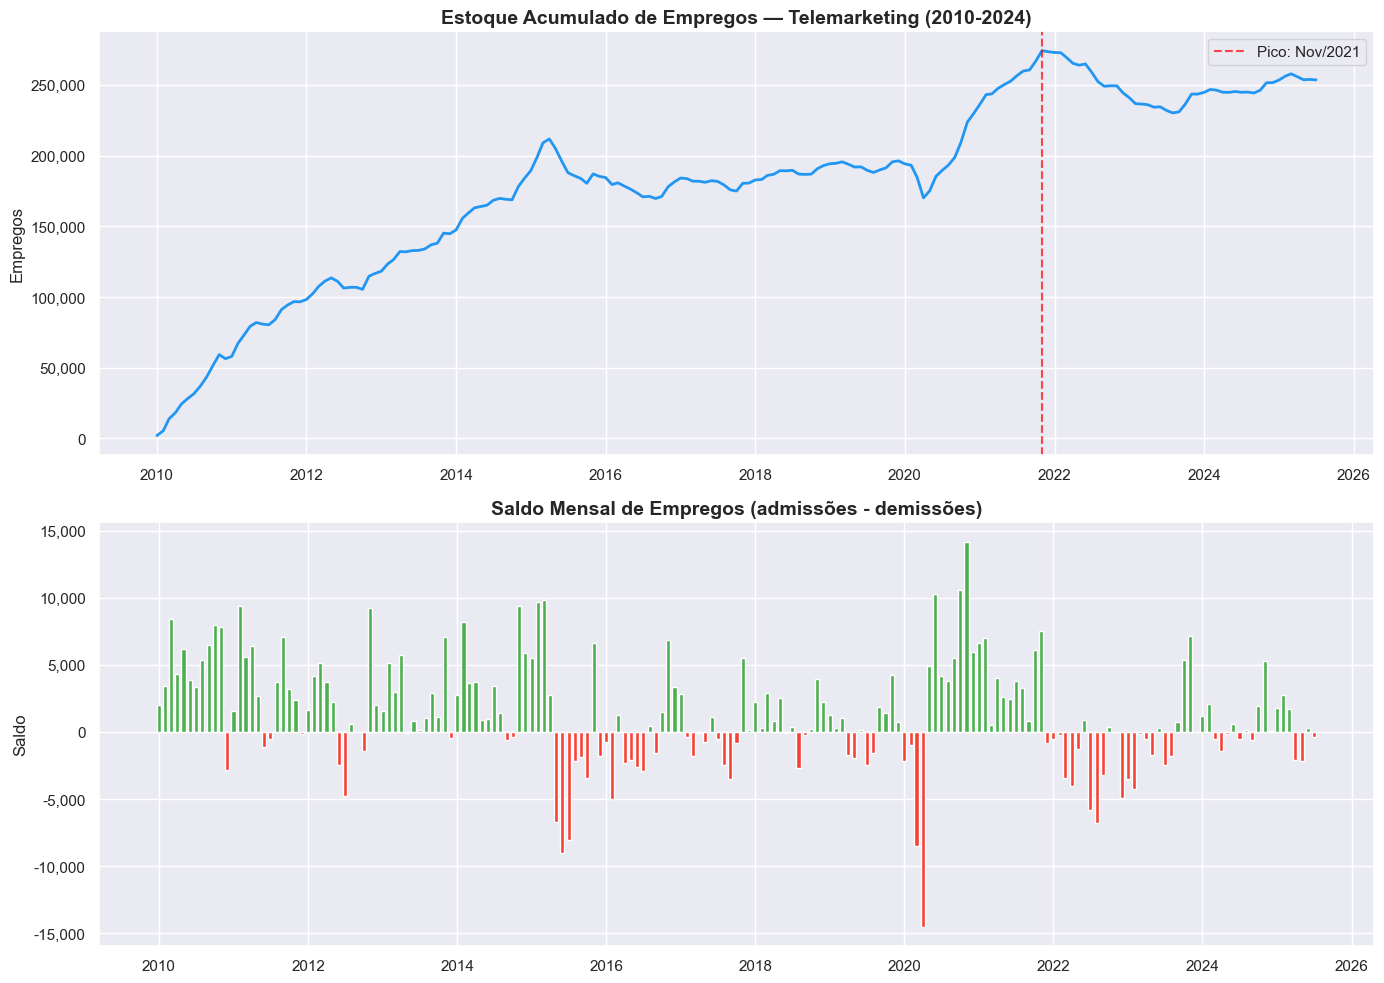

Gráfico salvo em output/serie_historica.png


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1 — Estoque acumulado
ax1.plot(df['data'], df['estoque_acumulado'], 
         color='#2196F3', linewidth=2)
ax1.axvline(x=data_pico, color='red', linestyle='--', 
            alpha=0.7, label=f'Pico: {data_pico.strftime("%b/%Y")}')
ax1.set_title('Estoque Acumulado de Empregos — Telemarketing (2010-2024)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Empregos')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Gráfico 2 — Saldo mensal
cores = ['#f44336' if x < 0 else '#4CAF50' for x in df['saldo_empregos']]
ax2.bar(df['data'], df['saldo_empregos'], color=cores, width=20)
ax2.axhline(y=0, color='white', linewidth=0.8)
ax2.set_title('Saldo Mensal de Empregos (admissões - demissões)', 
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Saldo')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../output/serie_historica.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo em output/serie_historica.png")

In [13]:
import basedosdados as bd
import os
os.environ['GOOGLE_CLOUD_PROJECT'] = 'telemarketing-decline'

In [14]:
query_recente = """
SELECT
    ano,
    mes,
    COUNT(*) as registros
FROM `basedosdados.br_me_caged.microdados_movimentacao`
WHERE
    cbo_2002 LIKE '4223%'
    AND ano >= 2024
GROUP BY
    ano, mes
ORDER BY
    ano, mes
"""

df_recente = bd.read_sql(
    query=query_recente,
    billing_project_id="telemarketing-decline"
)

print(df_recente)

Downloading: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|
     ano  mes  registros
0   2024    1      63353
1   2024    2      61379
2   2024    3      61796
3   2024    4      62574
4   2024    5      60061
5   2024    6      56265
6   2024    7      60813
7   2024    8      61822
8   2024    9      58014
9   2024   10      64846
10  2024   11      54659
11  2024   12      54305
12  2025    1      66200
13  2025    2      67328
14  2025    3      64756
15  2025    4      61079
16  2025    5      60364
17  2025    6      60855
18  2025    7      59678


In [15]:
# Verificar tendência de 2025
df_2025_view = df[df['ano'] == 2025].copy()

print("Dados de 2025:")
print(df_2025_view[['data', 'saldo_empregos', 'estoque_acumulado']])

valor_julho_2025 = df_2025_view['estoque_acumulado'].iloc[-1]
queda_2025 = valor_pico - valor_julho_2025
queda_pct_2025 = (queda_2025 / valor_pico) * 100

print(f"\nEstoque em Jul/2025: {valor_julho_2025:,.0f}")
print(f"Queda desde o pico: -{queda_2025:,.0f} empregos ({queda_pct_2025:.1f}%)")

Dados de 2025:
          data  saldo_empregos  estoque_acumulado
180 2025-01-01            1814             253356
181 2025-02-01            2734             256090
182 2025-03-01            1678             257768
183 2025-04-01           -2059             255709
184 2025-05-01           -2154             253555
185 2025-06-01             255             253810
186 2025-07-01            -344             253466

Estoque em Jul/2025: 253,466
Queda desde o pico: -20,729 empregos (7.6%)


In [16]:
# Salvar dado tratado atualizado
df.to_csv('../output/caged_telemarketing_tratado.csv', index=False)

print("Dado tratado salvo!")
print(f"\nResumo final do dataset:")
print(f"  Período: Jan/2010 a Jul/2025")
print(f"  Total de registros: {len(df)}")
print(f"  Pico de empregos: {data_pico.strftime('%b/%Y')} ({valor_pico:,.0f})")
print(f"  Nível atual Jul/2025: {valor_julho_2025:,.0f}")
print(f"  Queda desde o pico: -{queda_pct_2025:.1f}%")

Dado tratado salvo!

Resumo final do dataset:
  Período: Jan/2010 a Jul/2025
  Total de registros: 187
  Pico de empregos: Nov/2021 (274,195)
  Nível atual Jul/2025: 253,466
  Queda desde o pico: -7.6%
